In [18]:
import tensorflow as tf

In [ ]:
 x = tf.Variable(3, name="x")
 y = tf.Variable(4, name="y")
 f = x*x*y + y + 2

In [ ]:
# In TensorFlow 2.x, eager execution is enabled by default, so a session is not needed.
# The variables x and y are already initialized when they are created.

# evaluate f directly
result = f.numpy() # Use .numpy() to get the value of the tensor as a NumPy array
print(result)

42


In [ ]:
x1 = tf.Variable(1)
# x1.graph is tf.get_default_graph() # This line is removed as it's not valid in TF 2.x eager execution

In [ ]:
w = tf.constant(3)
x = w + 2
y = x + 5
z = x * 3
print(y.numpy())
print(z.numpy())

10
15


In [ ]:
 y_val, z_val = y, z
 print(y_val)
 print(z_val)

tf.Tensor(10, shape=(), dtype=int32)
tf.Tensor(15, shape=(), dtype=int32)


### Linear Regression with Tensorflow

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_california_housing

# Load and prepare data
housing = fetch_california_housing()
m, n = housing.data.shape
housing_data_plus_bias = np.c_[np.ones((m, 1)), housing.data]  # Add bias term (x0 = 1)

# Define TensorFlow constants (tensors)
X = tf.constant(housing_data_plus_bias, dtype=tf.float32, name="X")  # Shape: (m, n+1)
y = tf.constant(housing.target.reshape(-1, 1), dtype=tf.float32, name="y")  # Shape: (m, 1)

# Define normal equation: theta = (X^T X)^(-1) X^T y
XT = tf.transpose(X)  # Transpose: (n+1, m)
XTX = tf.matmul(XT, X)  # Matrix multiply: (n+1, m) * (m, n+1) = (n+1, n+1)
XTX_inv = tf.linalg.inv(XTX)  # Inverse: (n+1, n+1)
XTy = tf.matmul(XT, y)  # Matrix multiply: (n+1, m) * (m, 1) = (n+1, 1)
theta = tf.matmul(XTX_inv, XTy)  # Final theta: (n+1, 1)


 # Evaluate the graph to get theta
theta_value = theta.numpy()

print("Optimal parameters (theta):", theta_value)

Optimal parameters (theta): [[-3.7167969e+01]
 [ 4.3632507e-01]
 [ 9.3879700e-03]
 [-1.0710144e-01]
 [ 6.4526367e-01]
 [-4.1127205e-06]
 [-3.7808418e-03]
 [-4.2367554e-01]
 [-4.3707275e-01]]


In [ ]:
# Predict on a test instance
X_test = housing_data_plus_bias[:5]  # First 5 instances
y_pred = np.matmul(X_test, theta_value)  # Compute predictions
print("Predictions:", y_pred.flatten())
print("Actual:", housing.target[:5])

Predictions: [4.12563547 3.97111782 3.67079548 3.23588801 2.40863961]
Actual: [4.526 3.585 3.521 3.413 3.422]


### Using Batch Gradient Descent

Gradient Descent requires scaling the feature vectors first. We could do this using TF, but let's just use Scikit-Learn for now.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_housing_data = scaler.fit_transform(housing.data)
scaled_housing_data_plus_bias = np.c_[np.ones((m, 1)), scaled_housing_data]

In [ ]:
print(scaled_housing_data_plus_bias.mean(axis=0))
print(scaled_housing_data_plus_bias.mean(axis=1))
print(scaled_housing_data_plus_bias.mean())
print(scaled_housing_data_plus_bias.shape)

[ 1.00000000e+00  6.60969987e-17  5.50808322e-18  6.60969987e-17
 -1.06030602e-16 -1.10161664e-17  3.44255201e-18 -1.07958431e-15
 -8.52651283e-15]
[ 0.38915536  0.36424355  0.5116157  ... -0.06612179 -0.06360587
  0.01359031]
0.11111111111111005
(20640, 9)


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Load and preprocess data
housing = fetch_california_housing()
m, n = housing.data.shape
scaler = StandardScaler()
scaled_housing_data = scaler.fit_transform(housing.data)  # Normalize features
scaled_housing_data_plus_bias = np.c_[np.ones((m, 1)), scaled_housing_data]  # Add bias term

# Hyperparameters
n_epochs = 1000
learning_rate = 0.01

# TensorFlow tensors
X = tf.constant(scaled_housing_data_plus_bias, dtype=tf.float32, name="X")  # Shape: (m, n+1)
y = tf.constant(housing.target.reshape(-1, 1), dtype=tf.float32, name="y")  # Shape: (m, 1)
theta = tf.Variable(tf.random.uniform([n + 1, 1], -1.0, 1.0), name="theta")  # Random init

# Training loop
for epoch in range(n_epochs):
    y_pred = tf.linalg.matmul(X, theta, name="predictions")  # X * theta
    error = y_pred - y  # Prediction error
    mse = tf.reduce_mean(tf.square(error), name="mse")  # MSE loss
    gradients = 2/m * tf.linalg.matmul(tf.transpose(X), error)  # Gradient: (2/m) * X^T * error
    theta.assign_sub(learning_rate * gradients)  # Update: theta -= learning_rate * gradients

    if epoch % 100 == 0:  # Print MSE every 100 epochs
        print(f"Epoch {epoch}, MSE = {mse.numpy():.6f}")

# Final parameters
best_theta = theta.numpy()
print("Optimal theta:", best_theta.flatten())

Epoch 0, MSE = 12.996080
Epoch 100, MSE = 0.945295
Epoch 200, MSE = 0.699596
Epoch 300, MSE = 0.652336
Epoch 400, MSE = 0.619925
Epoch 500, MSE = 0.596042
Epoch 600, MSE = 0.578355
Epoch 700, MSE = 0.565213
Epoch 800, MSE = 0.555414
Epoch 900, MSE = 0.548080
Optimal theta: [ 2.0685523   0.87349635  0.16619126 -0.2750825   0.28134325  0.01218514
 -0.0442748  -0.5128611  -0.4850751 ]


### Using auto diff for automatically calculating gradient

In [ ]:
n_epochs = 1000
learning_rate = 0.01

# Initialize theta
theta = tf.Variable(tf.random.uniform([n + 1, 1], -1.0, 1.0), name="theta")  # Random init

# Define optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)  # Gradient Descent optimizer

# Training loop with autodiff
for epoch in range(n_epochs):
    with tf.GradientTape() as tape:  # Track operations for autodiff
        y_pred = tf.linalg.matmul(X, theta)  # Predictions
        error = y_pred - y
        mse = tf.reduce_mean(tf.square(error))  # MSE loss

    gradients = tape.gradient(mse, [theta])[0]  # Autodiff computes gradient
    optimizer.apply_gradients([(gradients, theta)])  # Update theta

    if epoch % 100 == 0:  # Print MSE every 100 epochs
        print(f"Epoch {epoch}, MSE = {mse.numpy():.6f}")

# Final parameters
best_theta = theta.numpy()
print("Optimal theta:", best_theta.flatten())

Epoch 0, MSE = 9.438034
Epoch 100, MSE = 0.719372
Epoch 200, MSE = 0.565670
Epoch 300, MSE = 0.553219
Epoch 400, MSE = 0.545848
Epoch 500, MSE = 0.540444
Epoch 600, MSE = 0.536448
Epoch 700, MSE = 0.533482
Epoch 800, MSE = 0.531274
Epoch 900, MSE = 0.529624
Optimal theta: [ 2.0685523e+00  7.5340998e-01  1.2343372e-01 -8.6059272e-02
  1.4168797e-01 -1.8104108e-03 -3.8097456e-02 -9.3731976e-01
 -8.9738864e-01]


### Mini Batch Gradient Descent

In [ ]:
# Hyperparameters
n_epochs = 10  # Reduced for demo
batch_size = 100
n_batches = int(np.ceil(m / batch_size))
learning_rate = 0.01

# Initialize theta
theta = tf.Variable(tf.random.uniform([n + 1, 1], -1.0, 1.0), name="theta")

# Optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

# Function to fetch mini-batch
def fetch_batch(epoch, batch_index, batch_size):
    np.random.seed(epoch * n_batches + batch_index)  # For reproducibility
    indices = np.random.randint(m, size=batch_size)
    # Convert NumPy indices to TensorFlow tensor
    tf_indices = tf.constant(indices, dtype=tf.int32)
    X_batch = tf.gather(X, tf_indices) # Use tf.gather for indexing with a tensor of indices
    y_batch = tf.gather(y, tf_indices) # Use tf.gather for indexing with a tensor of indices
    return X_batch, y_batch

# Training loop
for epoch in range(n_epochs):
    for batch_index in range(n_batches):
        X_batch, y_batch = fetch_batch(epoch, batch_index, batch_size)
        with tf.GradientTape() as tape:
            y_pred = tf.linalg.matmul(X_batch, theta)
            mse = tf.reduce_mean(tf.square(y_pred - y_batch))
        gradients = tape.gradient(mse, [theta])[0]
        optimizer.apply_gradients([(gradients, theta)])
    if epoch % 2 == 0:
        y_pred_full = tf.linalg.matmul(X, theta)
        mse_full = tf.reduce_mean(tf.square(y_pred_full - y))
        print(f"Epoch {epoch}, MSE = {mse_full.numpy():.6f}")

print("Optimal theta:", theta.numpy().flatten())

Epoch 0, MSE = 0.537862
Epoch 2, MSE = 0.532698
Epoch 4, MSE = 0.527411
Epoch 6, MSE = 0.526018
Epoch 8, MSE = 0.525227
Optimal theta: [ 2.0703032   0.85473067  0.11976179 -0.29794076  0.37459555  0.0034784
 -0.01152562 -0.86444    -0.832604  ]


### Modularity

In [ ]:
import tensorflow as tf
import numpy as np

# Define modular ReLU function
def relu(X, name="relu"):
    with tf.name_scope(name):
        n_features = int(X.shape[1])  # Get number of features
        w = tf.Variable(tf.random.normal((n_features, 1)), name="weights")
        b = tf.Variable(0.0, name="bias")
        z = tf.linalg.matmul(X, w) + b
        return tf.maximum(z, 0.0, name="relu")

# Small dataset
X = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]], dtype=tf.float32)  # Shape: (2, 3)

# Create 5 ReLUs
relus = [relu(X, name=f"relu_{i}") for i in range(5)]
output = tf.add_n(relus, name="output")

### Exercise QN 12. Logistic Regression with mini batch gradient descent in tensorflow

First, let's create the moons dataset using Scikit-Learn's make_moons() function:



In [1]:
from sklearn.datasets import make_moons

m = 1000
X_moons, y_moons = make_moons(m, noise=0.1, random_state=42)

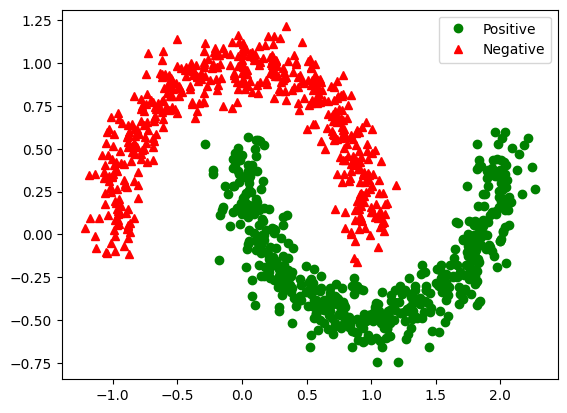

In [3]:
# visualizing the data
import matplotlib.pyplot as plt
plt.plot(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], 'go', label="Positive")
plt.plot(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], 'r^', label="Negative")
plt.legend()
plt.show()

In [5]:
# adding bias
import numpy as np
X_moons_with_bias = np.c_[np.ones((m, 1)), X_moons]

In [6]:
# let's check
X_moons_with_bias[:5]

array([[ 1.        , -0.05146968,  0.44419863],
       [ 1.        ,  1.03201691, -0.41974116],
       [ 1.        ,  0.86789186, -0.25482711],
       [ 1.        ,  0.288851  , -0.44866862],
       [ 1.        , -0.83343911,  0.53505665]])

Looks good. Now let's reshape y_train to make it a column vector (i.e. a 2D array with a single column):

In [9]:
# making the y_train a 2d array
y_moons_column_vector = y_moons.reshape(-1, 1)

In [11]:
# lets check y_moons_column_vector
y_moons_column_vector[:5]

array([[1],
       [1],
       [1],
       [1],
       [0]])

In [12]:
# splitting the data into train and test
test_ratio = 0.2
test_size = int(m * test_ratio)
X_train = X_moons_with_bias[:-test_size]
X_test = X_moons_with_bias[-test_size:]
y_train = y_moons_column_vector[:-test_size]
y_test = y_moons_column_vector[-test_size:]

In [13]:
# generate training batches
def random_batch(X_train, y_train, batch_size):
    rnd_indices = np.random.randint(0, len(X_train), batch_size)
    X_batch = X_train[rnd_indices]
    y_batch = y_train[rnd_indices]
    return X_batch, y_batch

In [14]:
X_batch, y_batch = random_batch(X_train, y_train, 5)
X_batch

array([[ 1.        ,  0.8149384 , -0.49147638],
       [ 1.        ,  2.03382173,  0.35493678],
       [ 1.        ,  1.10938723,  0.11885935],
       [ 1.        ,  0.00715274,  1.08970373],
       [ 1.        ,  0.9098371 ,  0.42506452]])

In [15]:
y_batch

array([[1],
       [1],
       [0],
       [0],
       [0]])

Great! Now that the data is ready to be fed to the model, we need to build that model. Let's start with a simple implementation, The moons dataset has two input features, since each instance is a point on a plane (i.e., 2-Dimensional):



In [16]:
n_inputs = 2

Now let's build the Logistic Regression model. As we saw in chapter 4, this model first computes a weighted sum of the inputs (just like the Linear Regression model), and then it applies the sigmoid function to the result, which gives us the estimated probability for the positive class:

In [20]:
# finding the sigmoid function
# Convert to tensors
X = tf.constant(X_moons_with_bias, dtype=tf.float32, name="X")  # Shape: (None, n_inputs + 1)
y = tf.constant(y_moons.reshape(-1, 1), dtype=tf.float32, name="y")  # Shape: (None, 1)

# Initialize parameters
theta = tf.Variable(tf.random.uniform([n_inputs + 1, 1], -1.0, 1.0, seed=42), name="theta")
logits = tf.matmul(X, theta, name="logits")
y_proba = 1 / (1 + tf.exp(-logits))

In [21]:
# using tf sigmoid function
y_proba = tf.sigmoid(logits)

In [23]:
# calculating log loss
loss = -tf.reduce_mean(y * tf.math.log(y_proba) + (1 - y) * tf.math.log(1 - y_proba))

In [29]:
# Define optimizer
learning_rate = 0.01
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

# Training loop
n_epochs = 3000
for epoch in range(n_epochs):
    with tf.GradientTape() as tape:
        logits = tf.linalg.matmul(X, theta)
        loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=logits))
    gradients = tape.gradient(loss, [theta])[0]
    optimizer.apply_gradients([(gradients, theta)])
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss.numpy():.6f}")


Epoch 0, Loss = 0.324667
Epoch 100, Loss = 0.322095
Epoch 200, Loss = 0.319674
Epoch 300, Loss = 0.317390
Epoch 400, Loss = 0.315230
Epoch 500, Loss = 0.313183
Epoch 600, Loss = 0.311241
Epoch 700, Loss = 0.309394
Epoch 800, Loss = 0.307635
Epoch 900, Loss = 0.305958
Epoch 1000, Loss = 0.304356
Epoch 1100, Loss = 0.302825
Epoch 1200, Loss = 0.301359
Epoch 1300, Loss = 0.299955
Epoch 1400, Loss = 0.298608
Epoch 1500, Loss = 0.297316
Epoch 1600, Loss = 0.296073
Epoch 1700, Loss = 0.294879
Epoch 1800, Loss = 0.293730
Epoch 1900, Loss = 0.292624
Epoch 2000, Loss = 0.291557
Epoch 2100, Loss = 0.290529
Epoch 2200, Loss = 0.289538
Epoch 2300, Loss = 0.288581
Epoch 2400, Loss = 0.287656
Epoch 2500, Loss = 0.286763
Epoch 2600, Loss = 0.285900
Epoch 2700, Loss = 0.285065
Epoch 2800, Loss = 0.284257
Epoch 2900, Loss = 0.283476


In [30]:
# Predictions for visualization
y_pred = tf.sigmoid(tf.linalg.matmul(X, theta)).numpy()
decision_boundary = y_pred >= 0.5

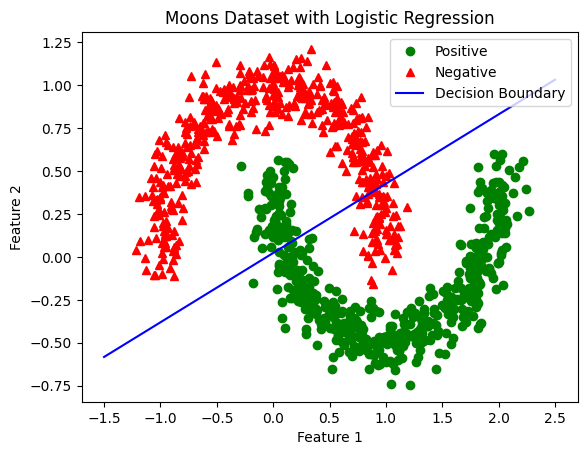

Optimal theta: [ 0.07324865  1.2862278  -3.1845849 ]


In [31]:
# Visualize data and decision boundary
plt.plot(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], 'go', label="Positive")
plt.plot(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], 'r^', label="Negative")
# Plot decision boundary (theta_0 + theta_1 * x1 + theta_2 * x2 = 0)
x1_range = np.linspace(-1.5, 2.5, 100)
x2_range = -(theta.numpy()[0] + theta.numpy()[1] * x1_range) / theta.numpy()[2]
plt.plot(x1_range, x2_range, 'b-', label="Decision Boundary")
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset with Logistic Regression")
plt.show()

print("Optimal theta:", theta.numpy().flatten())

In [32]:
# Compute predictions
y_proba = tf.sigmoid(tf.linalg.matmul(X, theta)).numpy()
y_pred = (y_proba >= 0.5).astype(np.int32).flatten()  # Predicted classes (0 or 1)

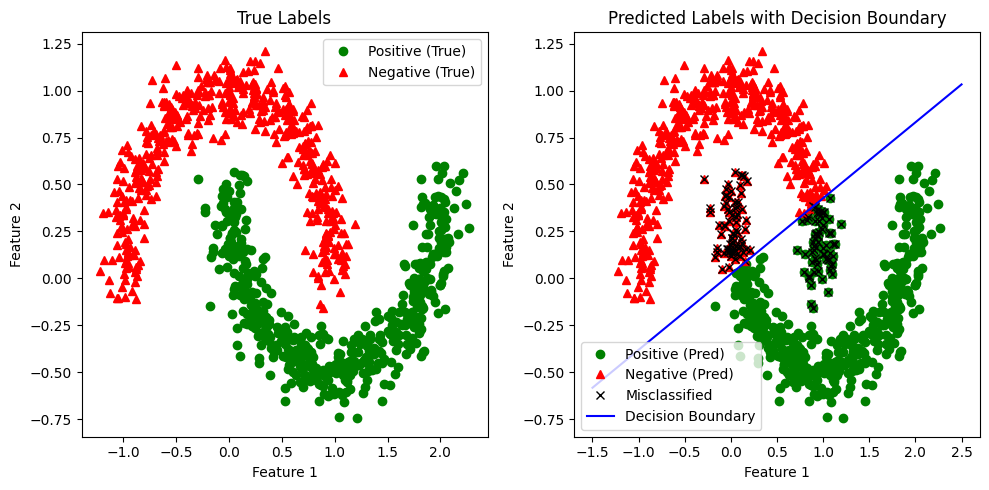

Optimal theta: [ 0.07324865  1.2862278  -3.1845849 ]
Accuracy: 0.8640


In [33]:
# Visualize true labels and predictions
plt.figure(figsize=(10, 5))

# Plot 1: True labels
plt.subplot(1, 2, 1)
plt.plot(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], 'go', label="Positive (True)")
plt.plot(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], 'r^', label="Negative (True)")
plt.title("True Labels")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

# Plot 2: Predicted labels with decision boundary
plt.subplot(1, 2, 2)
plt.plot(X_moons[y_pred == 1, 0], X_moons[y_pred == 1, 1], 'go', label="Positive (Pred)")
plt.plot(X_moons[y_pred == 0, 0], X_moons[y_pred == 0, 1], 'r^', label="Negative (Pred)")
# Highlight misclassified points
misclassified = y_pred != y_moons
plt.plot(X_moons[misclassified, 0], X_moons[misclassified, 1], 'kx', label="Misclassified")
# Plot decision boundary (theta_0 + theta_1 * x1 + theta_2 * x2 = 0)
x1_range = np.linspace(-1.5, 2.5, 100)
x2_range = -(theta.numpy()[0] + theta.numpy()[1] * x1_range) / theta.numpy()[2]
plt.plot(x1_range, x2_range, 'b-', label="Decision Boundary")
plt.title("Predicted Labels with Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.tight_layout()
plt.show()

print("Optimal theta:", theta.numpy().flatten())
# Calculate accuracy
accuracy = np.mean(y_pred == y_moons)
print(f"Accuracy: {accuracy:.4f}")